# Intensity Transformations and Neighborhood Filtering

## Q 01

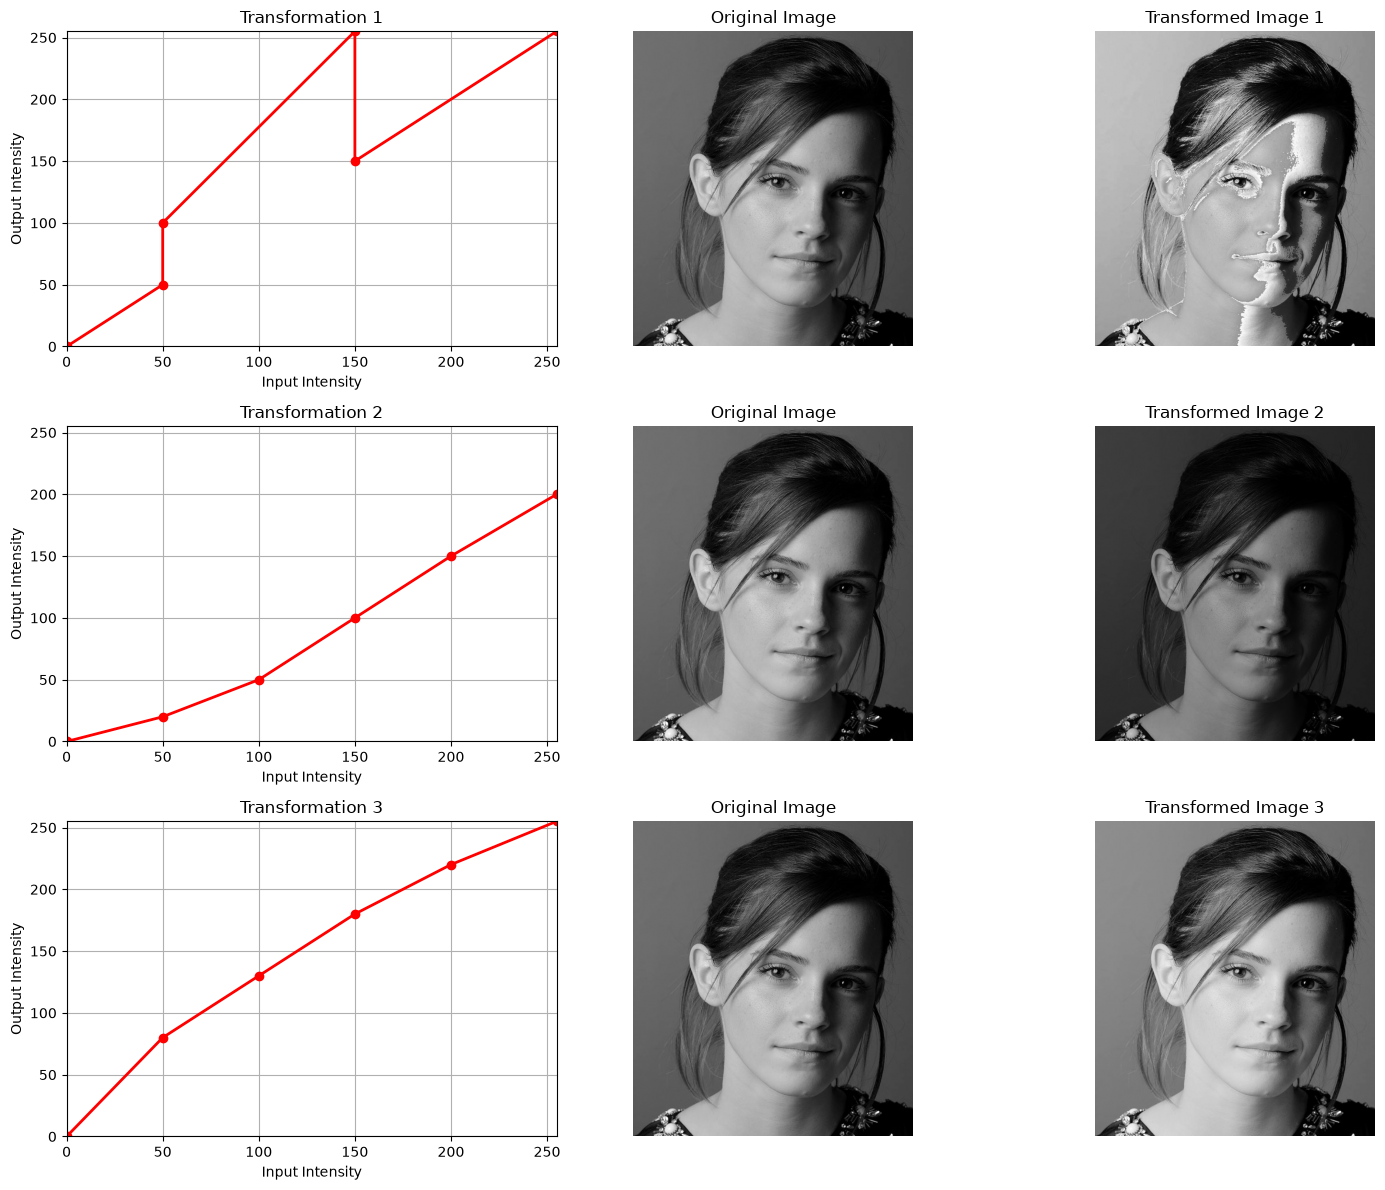

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def intensity_transform(im: np.ndarray, breakpoints: list) -> np.ndarray:
    bp = np.array(breakpoints, dtype=np.float32)
    x_in = np.arange(256)
    lut = np.interp(x_in, bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv.LUT(im, lut)


# Load image
img = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)


# Three different breakpoint sets
breakpoints_list = [
    [
        [0, 0],
        [50, 50],
        [50, 100],
        [150, 255],
        [150, 150],
        [255, 255]
    ],

    [
        [0, 0],
        [50, 20],
        [100, 50],
        [150, 100],
        [200, 150],
        [255, 200]
    ],

    [
        [0, 0],
        [50, 80],
        [100, 130],
        [150, 180],
        [200, 220],
        [255, 255]
    ]
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))


for row, breakpoints in enumerate(breakpoints_list):
    transformed_img = intensity_transform(img, breakpoints)

    bp = np.array(breakpoints)

    # Column 1: Transformation curve
    axes[row, 0].plot(bp[:, 0],bp[:, 1],'r-o',linewidth=2)
    axes[row, 0].set_title(f'Transformation {row + 1}')

    axes[row, 0].set_xlabel('Input Intensity')
    axes[row, 0].set_ylabel('Output Intensity')
    axes[row, 0].set_xlim([0, 255])
    axes[row, 0].set_ylim([0, 255])
    axes[row, 0].grid(True)

    # Column 2: Original image
    axes[row, 1].imshow(img,cmap='gray',vmin=0,vmax=255)
    axes[row, 1].set_title('Original Image')
    axes[row, 1].axis('off')

    # Column 3: Transformed image
    axes[row, 2].imshow(transformed_img,cmap='gray',vmin=0,vmax=255)
    axes[row, 2].set_title(f'Transformed Image {row + 1}')
    axes[row, 2].axis('off')


plt.tight_layout()
plt.show()

## Q 02

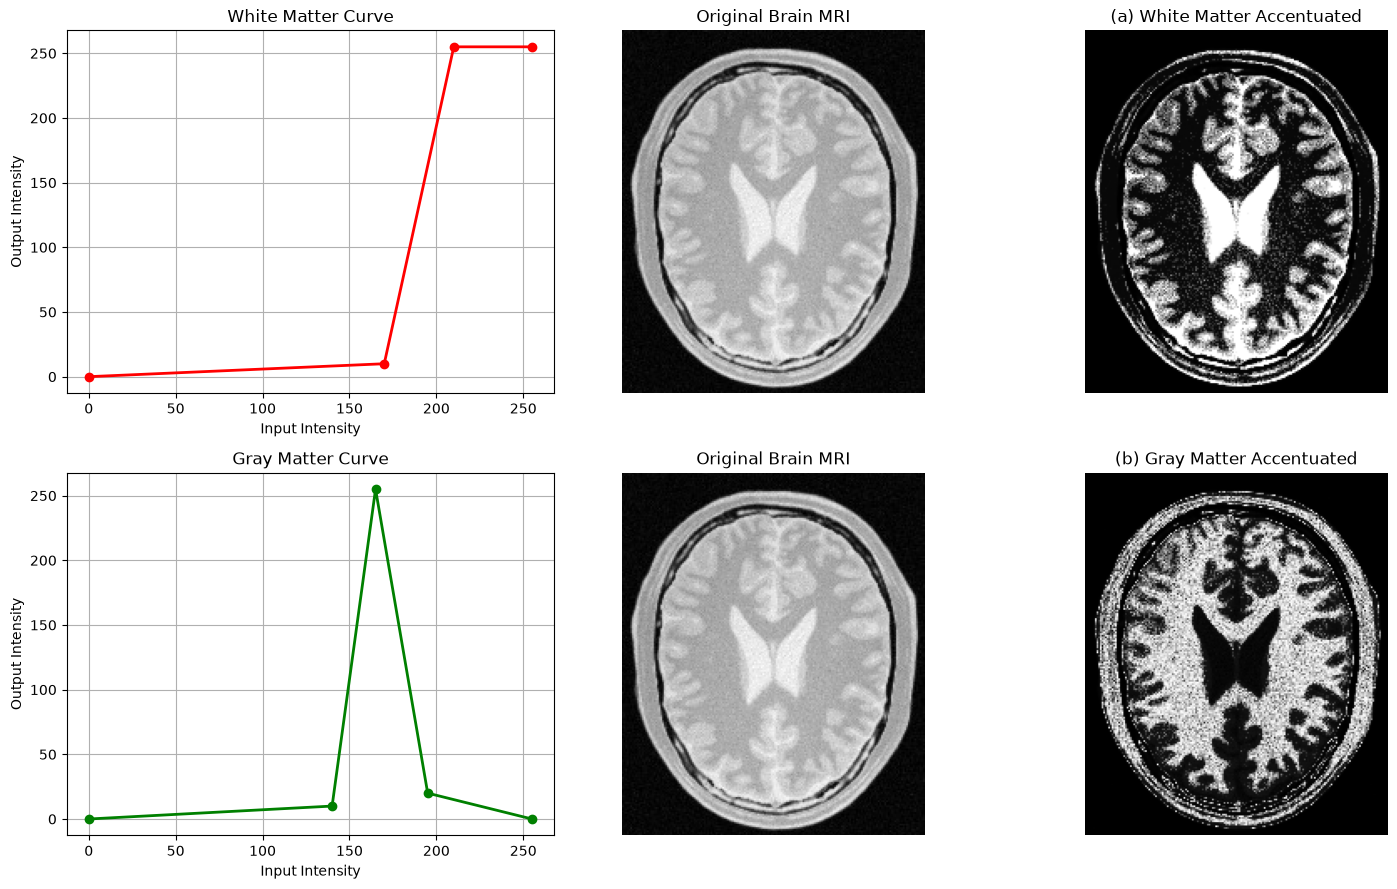

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im: np.ndarray, breakpoints: list) -> np.ndarray:
    """Applies piecewise linear intensity transformation using lookup table."""
    bp = np.array(breakpoints, dtype=np.float32)
    x = np.arange(256)
    lut = np.interp(x, bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv.LUT(im, lut)

img = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
bp_white_matter = [
    [0, 0],
    [170, 10],
    [210, 255],
    [255, 255]
]

bp_gray_matter = [
    [0, 0],
    [140, 10],
    [165, 255],
    [195, 20],
    [255, 0]
]

img_wm = intensity_transform(img, bp_white_matter)
img_gm = intensity_transform(img, bp_gray_matter)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
#plot white matter transformation curve and images
bp_wm = np.array(bp_white_matter)

axes[0, 0].plot(bp_wm[:, 0], bp_wm[:, 1], 'r-o', linewidth=2)
axes[0, 0].set_title('White Matter Curve')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].grid(True)

axes[0, 1].imshow(img, cmap='gray')
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray')
axes[0, 2].set_title('(a) White Matter Accentuated')
axes[0, 2].axis('off')

#plot gray matter transformation curve and images
bp_gm = np.array(bp_gray_matter)
axes[1, 0].plot(bp_gm[:, 0], bp_gm[:, 1], 'g-o', linewidth=2)
axes[1, 0].set_title('Gray Matter Curve')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].grid(True)

axes[1, 1].imshow(img, cmap='gray')
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray')
axes[1, 2].set_title('(b) Gray Matter Accentuated')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Histogram plots


C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1].hist(img_wm.ravel(), 256, [0, 256], color='crimson', alpha=0.8)
C:\Users\User\AppData\Local\Temp\ipykernel_14244\1097912072.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[2].hist(img_gm.ravel(), 256, [0, 256], color='forestgreen', alpha=0.8)


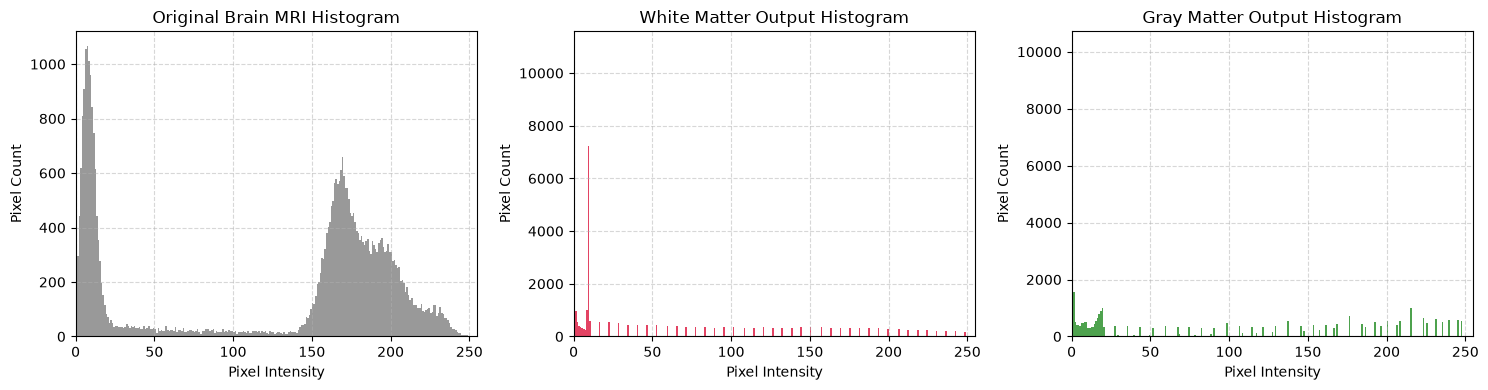

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Original Brain MRI Histogram
axes[0].hist(img.ravel(), 256, [0, 256], color='gray', alpha=0.8)
axes[0].set_title('Original Brain MRI Histogram')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Pixel Count')
axes[0].set_xlim([0, 255])
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. White Matter Accentuated Histogram
axes[1].hist(img_wm.ravel(), 256, [0, 256], color='crimson', alpha=0.8)
axes[1].set_title('White Matter Output Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Pixel Count')
axes[1].set_xlim([0, 255])
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Gray Matter Accentuated Histogram
axes[2].hist(img_gm.ravel(), 256, [0, 256], color='forestgreen', alpha=0.8)
axes[2].set_title('Gray Matter Output Histogram')
axes[2].set_xlabel('Pixel Intensity')
axes[2].set_ylabel('Pixel Count')
axes[2].set_xlim([0, 255])
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()